## Modelo de Regresión con XGBoost

Entrenamiento de un modelo XGBoost para predecir las ganancias totales diarias usando los datos de entrenamiento, validación y prueba.

#### Librerías necesarias

- Matplotlib: para la visualización de resultados y comparaciones.

Las librerías utilizadas para el modelado con XGBoost son las siguientes:- Scikit-learn: para las métricas de evaluación del modelo (MAPE, R², RMSE).

- XGBoost: para el algoritmo de regresión basado en gradient boosting.

- Pandas: para la manipulación y análisis de datos.- NumPy: para operaciones numéricas y cálculos.

In [48]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt

#### Carga del dataset.

Se cargan los datasets de entrenamiento, validación y prueba desde los archivos CSV generados en el paso de preprocesamiento. Estos conjuntos contienen las características preprocesadas y normalizadas listas para ser usadas en el modelo de regresión.

In [49]:
df_train = pd.read_csv('../../output/regresion/data_train_regresion.csv', encoding='ISO-8859-1')
df_validation = pd.read_csv('../../output/regresion/data_validation_regresion.csv', encoding='ISO-8859-1')
df_test = pd.read_csv('../../output/regresion/data_test_regresion.csv', encoding='ISO-8859-1')

print(f"Train: {df_train.shape}")
print(f"Validation: {df_validation.shape}")
print(f"Test: {df_test.shape}")
print(f"\nColumnas: {df_train.columns.tolist()}")

Train: (220, 9)
Validation: (55, 9)
Test: (17, 9)

Columnas: ['GananciasTotales', 'DiaMes', 'Lag_1_Ventas', 'DiaSemana_Domingo', 'DiaSemana_Jueves', 'DiaSemana_Lunes', 'DiaSemana_Martes', 'DiaSemana_Miercoles', 'DiaSemana_Viernes']


#### Preparación de features y target

Se separan las características (features) de la variable objetivo (target) en los datasets de entrenamiento, validación y prueba. La variable objetivo es 'GananciasTotales', que representa las ganancias totales diarias que se desea predecir. Las características incluyen variables como el día de la semana, día del mes, ventas del día anterior y otras variables preprocesadas.

In [50]:
X_train = df_train.drop('GananciasTotales', axis=1)
y_train = df_train['GananciasTotales'].values

X_validation = df_validation.drop('GananciasTotales', axis=1)
y_validation = df_validation['GananciasTotales'].values

X_test = df_test.drop('GananciasTotales', axis=1)
y_test = df_test['GananciasTotales'].values

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nPrimeras 5 filas de X_train:")
print(X_train.head())

X_train shape: (220, 8)
y_train shape: (220,)

Primeras 5 filas de X_train:
   DiaMes  Lag_1_Ventas  DiaSemana_Domingo  DiaSemana_Jueves  DiaSemana_Lunes  \
0       2      1.525539                0.0               1.0              0.0   
1       3      0.942194                0.0               0.0              0.0   
2       5      0.843943                1.0               0.0              0.0   
3       6      0.593427                0.0               0.0              1.0   
4       7      2.180166                0.0               0.0              0.0   

   DiaSemana_Martes  DiaSemana_Miercoles  DiaSemana_Viernes  
0               0.0                  0.0                0.0  
1               0.0                  0.0                1.0  
2               0.0                  0.0                0.0  
3               0.0                  0.0                0.0  
4               1.0                  0.0                0.0  


#### Entrenamiento modelo XGBoost.

A continuación se entrena el modelo XGBoost utilizando el dataset de entrenamiento. XGBoost es un algoritmo de gradient boosting que combina múltiples árboles de decisión débiles para crear un modelo de predicción fuerte. Se ajustan los hiperparámetros para optimizar el rendimiento, incluyendo el número de rondas de boosting, profundidad máxima de árboles, tasa de aprendizaje y fracciones de muestreo.

In [51]:
model = xgb.XGBRegressor(
  n_estimators=100,
  max_depth=5,
  learning_rate=0.05,
  subsample=0.8,
  colsample_bytree=0.8,
  random_state=42,
)

model.fit(X_train, y_train, verbose=False)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


#### Evaluación del modelo.

Se evalúa el rendimiento del modelo en los tres conjuntos de datos (entrenamiento, validación y prueba) utilizando las siguientes métricas:

Estas métricas permiten detectar posible overfitting (diferencia significativa entre train y test) y evaluar qué tan bien el modelo generaliza a datos nuevos. Un modelo bien ajustado debe mostrar métricas similares en entrenamiento y test.

- MAE (Mean Absolute Error): error medio absoluto en euros, interpretable directamente.

- R² (Coeficiente de Determinación): proporción de varianza en los datos explicada por el modelo (0-100%).- RMSE (Root Mean Squared Error): raíz del error cuadrático medio, sensible a errores grandes.

In [52]:
y_train_pred = model.predict(X_train)
y_validation_pred = model.predict(X_validation)
y_test_pred = model.predict(X_test)

def evaluar_modelo(y_true, y_pred):
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  r2 = r2_score(y_true, y_pred)
  return mae, r2, rmse

mae_train, r2_train, rmse_train = evaluar_modelo(y_train, y_train_pred)
print(f"\nENTRENAMIENTO:")
print(f"  MAE:  {mae_train:.2f}")
print(f"  R²:    {r2_train:.2f}")
print(f"  RMSE:  {rmse_train:.2f}")
mae_validation, r2_validation, rmse_validation = evaluar_modelo(y_validation, y_validation_pred)
print(f"\nVALIDACIÓN:")
print(f"  MAE:  {mae_validation:.2f}")
print(f"  R²:    {r2_validation:.2f}")
print(f"  RMSE:  {rmse_validation:.2f}")
mae_test, r2_test, rmse_test = evaluar_modelo(y_test, y_test_pred)
print(f"\nTEST:")
print(f"  MAE:  {mae_test:.2f}")
print(f"  R²:    {r2_test:.2f}")
print(f"  RMSE:  {rmse_test:.2f}")


ENTRENAMIENTO:
  MAE:  0.23
  R²:    0.87
  RMSE:  0.29

VALIDACIÓN:
  MAE:  0.87
  R²:    -0.66
  RMSE:  1.13

TEST:
  MAE:  1.20
  R²:    -1.88
  RMSE:  1.37


#### Importancia de features.

Se analizan las características más importantes del modelo XGBoost. XGBoost proporciona una puntuación de importancia para cada característica basada en cuánto reducen la función de pérdida durante el entrenamiento.

Comparar la importancia entre XGBoost y Random Forest puede proporcionar insights adicionales sobre la importancia relativa de cada característica.

Esta información revela:

- Oportunidades para simplificar el modelo eliminando características de baja importancia.

- Las variables con mayor poder predictivo para las ganancias diarias.- Posibles relaciones entre variables independientes y la variable objetivo.
- Características que el modelo considera más discriminativas.


Importancia de features:
            feature  importance
  DiaSemana_Domingo    0.550507
   DiaSemana_Jueves    0.097059
   DiaSemana_Martes    0.077752
       Lag_1_Ventas    0.074374
    DiaSemana_Lunes    0.070798
  DiaSemana_Viernes    0.050360
             DiaMes    0.041029
DiaSemana_Miercoles    0.038120


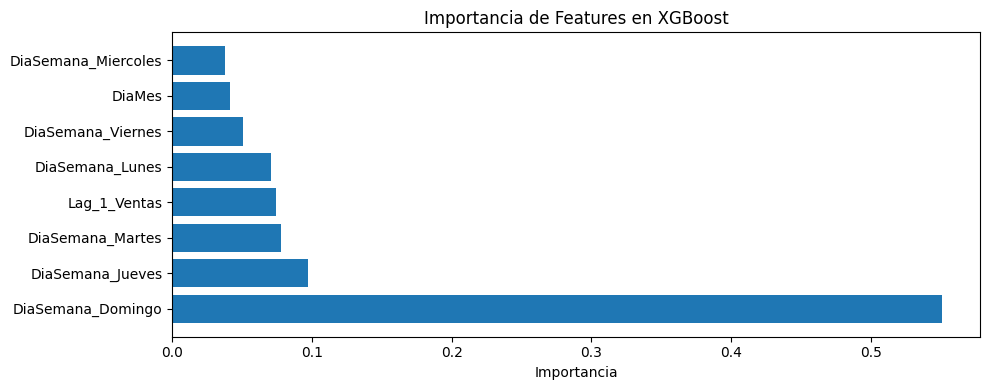

In [55]:
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
  'feature': X_train.columns,
  'importance': importances
}).sort_values('importance', ascending=False)

print("\nImportancia de features:")
print(feature_importance_df.to_string(index=False))

plt.figure(figsize=(10, 4))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importancia')
plt.title('Importancia de Features en XGBoost')
plt.tight_layout()
plt.show()

#### Visualización de predicciones vs realidad.

Se visualizan las predicciones del modelo comparadas con los valores reales en los tres conjuntos de datos. Esta visualización permite observar:

Los títulos muestran el MAPE (error porcentual medio) para facilitar la comparación rápida del rendimiento entre los tres conjuntos.

- **Seguimiento de patrones**: si el modelo captura correctamente las tendencias y fluctuaciones de las ganancias diarias.

- **Sesgo sistemático**: si el modelo tiende a sobrestimar o subestimar consistentemente los valores.- **Errores grandes**: identificar períodos o valores donde el modelo falla más.

- **Volatilidad**: la capacidad del modelo para predecir picos y valles en los datos.- **Generalización**: comparar visualmente si el modelo mantiene su precisión entre entrenamiento, validación y test.

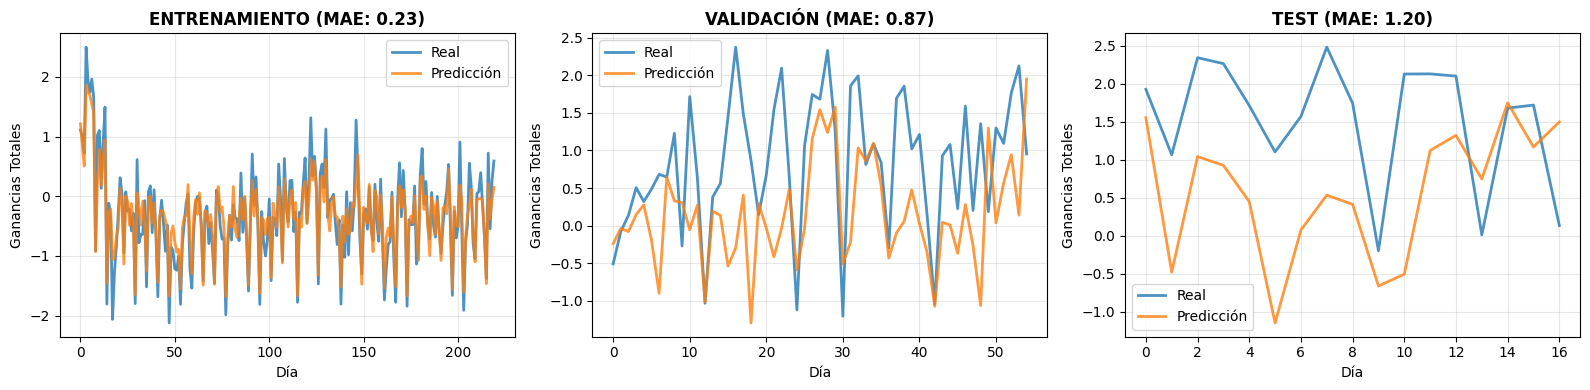

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(y_train, label='Real', linewidth=2, alpha=0.8)
axes[0].plot(y_train_pred, label='Predicción', linewidth=2, alpha=0.8)
axes[0].set_title(f'ENTRENAMIENTO (MAE: {mae_train:.2f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Día')
axes[0].set_ylabel('Ganancias Totales')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(y_validation, label='Real', linewidth=2, alpha=0.8)
axes[1].plot(y_validation_pred, label='Predicción', linewidth=2, alpha=0.8)
axes[1].set_title(f'VALIDACIÓN (MAE: {mae_validation:.2f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Ganancias Totales')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(y_test, label='Real', linewidth=2, alpha=0.8)
axes[2].plot(y_test_pred, label='Predicción', linewidth=2, alpha=0.8)
axes[2].set_title(f'TEST (MAE: {mae_test:.2f})', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Día')
axes[2].set_ylabel('Ganancias Totales')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()